# K-Means Clustering para Pricing — Lubrax

Modelo recomeçado do zero com o conjunto de features expandido (Fase 2): além das 5 features originais, incluímos `recencia_dias`, `concentracao_familia` e `intensidade_desconto`, que passaram no filtro de correlação de Spearman (nenhuma ≥ 0,90 com as demais — ver `1.EDA_Kmeans.ipynb`, seção 9.1).

`frequencia_mensal` (contagem bruta de transações) foi removida por problema de qualidade de dado: pedidos da Lubrax às vezes são faturados em várias remessas/dias, inflando artificialmente a contagem. A versão corrigida (`frequencia_mensal_corrigida`, via `pedidos.csv`) foi testada por ablação na seção 14 — melhora silhueta/DB, mas dissolve o cluster Especial; mantida só como enriquecimento. `cnae_descricao` (CNAE, via cruzamento CNPJ → Receita Federal, seção 9.2 do EDA) substitui `segmento_b2b` como dimensão de enriquecimento/leitura do perfil de cada cluster — fica de fora do treino pelo mesmo motivo: categórica com centenas de categorias (one-hot dominaria a distância euclidiana), além de ~3% sem cobertura.

Este notebook não assume k=5 de antemão: o k ótimo é recalculado do zero para o conjunto expandido de features.


## 0. Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='deep')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
EDA_CACHE = ROOT / 'outputs' / '1. EDA' / 'kmeans_clientes_features.pkl'
OUTPUT_DIR = ROOT / 'outputs' / '2. Clusterização'
FIG_DIR = OUTPUT_DIR / '5.Figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Diretório raiz: {ROOT}")
print(f"Saída será gravada em: {OUTPUT_DIR}")


Diretório raiz: C:\Volix\vibra-lubrax
Saída será gravada em: C:\Volix\vibra-lubrax\outputs\2. Clusterização


## 1. Funções auxiliares

In [2]:
def interpretar_silhueta(s):
    if s > 0.5:
        return "Excelente"
    elif s > 0.3:
        return "Aceitável"
    return "Fraco"

def interpretar_db(db):
    if db < 1.0:
        return "Excelente"
    elif db < 1.5:
        return "Aceitável"
    return "Fraco"

def interpretar_balance(pct):
    if pct < 2:
        return "Muito desbalanceado (cluster residual/outlier)"
    elif pct < 15:
        return "Desbalanceado, mas usável comercialmente"
    return "Bem balanceado"

def sweep_k(X_scaled, k_range, n_init=20, seed=42):
    """Treina KMeans para cada k em k_range e retorna (tabela comparativa, modelos treinados)."""
    rows = []
    modelos = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=seed, n_init=n_init, max_iter=500, tol=1e-4)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        unique, counts = np.unique(labels, return_counts=True)
        rows.append({
            'k': k, 'inercia': km.inertia_, 'silhueta': sil, 'davies_bouldin': db,
            'min_cluster': int(counts.min()), 'max_cluster': int(counts.max()),
            'balance_%': counts.min() / counts.max() * 100,
        })
        modelos[k] = (km, labels)
    return pd.DataFrame(rows), modelos

def salvar_csv(df, filename, dirs, **kwargs):
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        df.to_csv(d / filename, **kwargs)
    print(f"✓ {filename} salvo em: {', '.join(d.name for d in dirs)}")

def plot_comparativo_k(cmp_df, k_escolhido, titulo, dirs, filename='comparativo_k.png'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(cmp_df['k'], cmp_df['silhueta'], 'go-', linewidth=2, markersize=10)
    axes[0].axvline(x=k_escolhido, color='red', linestyle='--', linewidth=2, label=f'Escolhido (k={k_escolhido})')
    axes[0].axhline(y=0.5, color='orange', linestyle=':', linewidth=1, label='Limite excelência')
    axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhueta Score')
    axes[0].set_title('Silhueta (maior é melhor)', fontweight='bold')
    axes[0].grid(True, alpha=0.3); axes[0].legend(); axes[0].set_xticks(cmp_df['k'])

    axes[1].plot(cmp_df['k'], cmp_df['davies_bouldin'], 'ro-', linewidth=2, markersize=10)
    axes[1].axvline(x=k_escolhido, color='red', linestyle='--', linewidth=2, label=f'Escolhido (k={k_escolhido})')
    axes[1].axhline(y=1.0, color='orange', linestyle=':', linewidth=1, label='Limite excelência')
    axes[1].set_xlabel('k'); axes[1].set_ylabel('Davies-Bouldin Index')
    axes[1].set_title('Davies-Bouldin (menor é melhor)', fontweight='bold')
    axes[1].grid(True, alpha=0.3); axes[1].legend(); axes[1].set_xticks(cmp_df['k'])

    axes[2].plot(cmp_df['k'], cmp_df['inercia'], 'bo-', linewidth=2, markersize=10)
    axes[2].axvline(x=k_escolhido, color='red', linestyle='--', linewidth=2, label=f'Escolhido (k={k_escolhido})')
    axes[2].set_xlabel('k'); axes[2].set_ylabel('Inércia')
    axes[2].set_title('Elbow Method', fontweight='bold')
    axes[2].grid(True, alpha=0.3); axes[2].legend(); axes[2].set_xticks(cmp_df['k'])

    fig.suptitle(titulo, fontweight='bold')
    plt.tight_layout()
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        plt.savefig(d / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ {filename} salvo em: {', '.join(d.name for d in dirs)}")


## 2. Carregar dataset do EDA

Já vem com `cnae_descricao`, `recencia_dias`, `concentracao_familia` e `intensidade_desconto` calculados (seções 9.1 e 9.2 do `1.EDA_Kmeans.ipynb`).


In [3]:
customer_features = pd.read_pickle(EDA_CACHE)
print(f"Clientes: {len(customer_features):,} | Colunas: {list(customer_features.columns)}")


Clientes: 7,332 | Colunas: ['Código Cliente', 'nome_cliente', 'transacoes', 'meses_ativos', 'produtos', 'volume_total', 'segmento_b2b', 'receita_liquida_total', 'lucro_reposicao_total', 'volume_medio', 'volume_std', 'ultima_compra', 'preco_liquido_ponderado', 'margem_pct_ponderada', 'frequencia_mensal', 'cv_volume', 'registros_totais', 'devolucoes', 'ajustes', 'inconsistencias', 'taxa_devolucao', 'taxa_ajuste', 'taxa_inconsistencia', 'recencia_dias', 'concentracao_familia', 'intensidade_desconto', 'frequencia_mensal_corrigida', 'cnpj_14', 'cnae_codigo', 'cnae_descricao', 'cnae_divisao', 'cnae_divisao_nome', 'estado_cliente', 'frete_por_m3']


## 3. Definição das features do modelo (final)

Histórico de decisões, todas feitas por evidência (correlação + teste de ablação, mesma população e k, comparando silhueta/Davies-Bouldin/ARI):

- **`frequencia_mensal` removida** — versão original (transações ÷ meses ativos) inflada por pedidos faturados em várias remessas (Teste 6). A versão corrigida (`frequencia_mensal_corrigida`, via `pedidos.csv`) foi testada por ablação (seção 14): melhora silhueta e Davies-Bouldin, mas dissolve o cluster Especial dentro do Pequeno — mantida como enriquecimento, não como feature.
- **`taxa_devolucao` removida** — pedido direto do cliente.
- **Família AV excluída da base** — pedido do cliente (seção 9 do `1.EDA_Kmeans.ipynb`); 175 clientes que só compravam AV saem do modelo.
- **`intensidade_desconto` testada e removida** — piorava silhueta (0,2951 vs. 0,3345) e Davies-Bouldin (1,1861 vs. 1,0961) sem reorganizar os clusters (ARI=0,998).
- **`concentracao_familia` testada e removida** — ao lado de `produtos` (correlação -0,75), remover qualquer uma das duas melhorava silhueta/DB; optamos por manter `produtos` (mais simples de explicar: contagem de SKUs distintos) e remover `concentracao_familia`.

Conjunto final: 5 features.


In [4]:
FEATURES = [
    'volume_total', 'preco_liquido_ponderado', 'margem_pct_ponderada', 'produtos', 'recencia_dias',
]
print(f"Features do modelo ({len(FEATURES)}): {FEATURES}")

n_antes = len(customer_features)
data = customer_features[
    (customer_features['volume_total'] > 0) &
    (customer_features['receita_liquida_total'] > 0) &
    (customer_features['margem_pct_ponderada'].notna())
].copy()

data_pre_outlier = data.copy()

# Corte de outliers extremos (percentis 1%-99%) — volume e preço têm caudas muito longas,
# o que distorce a distância euclidiana e isola esses clientes em clusters de 1 a poucos casos.
outlier_cols = ['volume_total', 'preco_liquido_ponderado']
mask = pd.Series(True, index=data.index)
for col in outlier_cols:
    q01, q99 = data[col].quantile([0.01, 0.99])
    mask &= data[col].between(q01, q99)
    print(f"{col}: mantendo faixa [{q01:.2f}, {q99:.2f}]")
data = data[mask].copy()
print(f"Clientes: {n_antes:,} -> {len(data):,} após filtros de qualidade e corte de outliers")


Features do modelo (5): ['volume_total', 'preco_liquido_ponderado', 'margem_pct_ponderada', 'produtos', 'recencia_dias']
volume_total: mantendo faixa [0.03, 165.14]
preco_liquido_ponderado: mantendo faixa [8966.07, 28884.59]
Clientes: 7,332 -> 7,050 após filtros de qualidade e corte de outliers


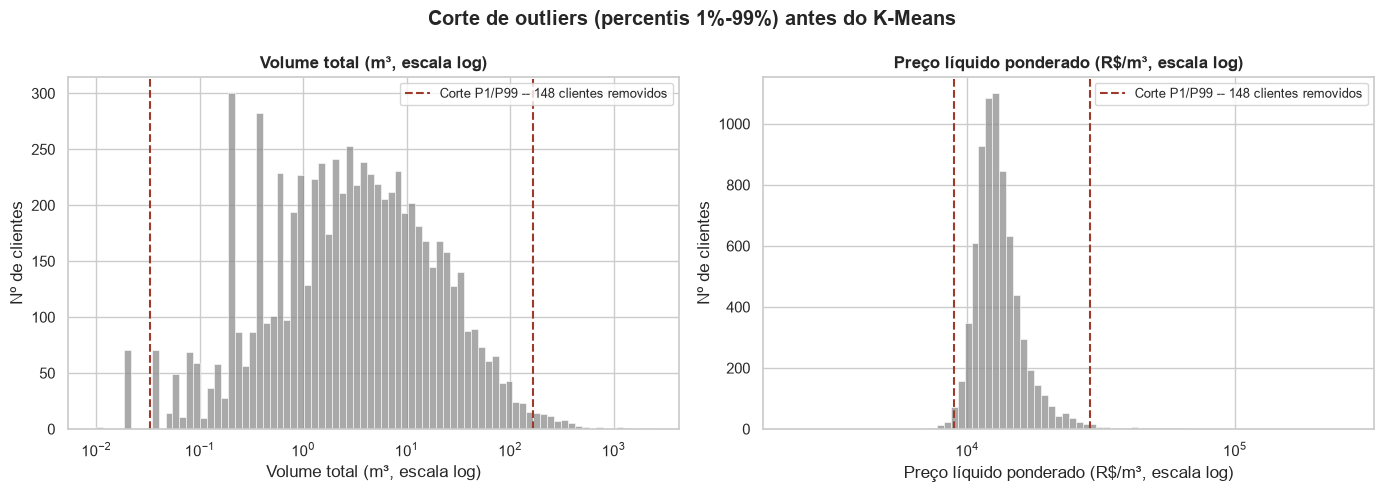

✓ 00_corte_outliers.png salvo


In [5]:
labels_outlier = {'volume_total': 'Volume total (m³, escala log)',
                   'preco_liquido_ponderado': 'Preço líquido ponderado (R$/m³, escala log)'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, outlier_cols):
    q01, q99 = data_pre_outlier[col].quantile([0.01, 0.99])
    n_removidos = (~data_pre_outlier[col].between(q01, q99)).sum()
    sns.histplot(data_pre_outlier[col], bins=80, ax=ax, color='#8C8C8C', log_scale=True)
    ax.axvline(q01, color='#9E3A2C', linestyle='--', linewidth=1.5)
    ax.axvline(q99, color='#9E3A2C', linestyle='--', linewidth=1.5,
               label=f'Corte P1/P99 -- {n_removidos} clientes removidos')
    ax.set_title(labels_outlier[col], fontweight='bold')
    ax.set_xlabel(labels_outlier[col]); ax.set_ylabel('Nº de clientes')
    ax.legend(fontsize=9, loc='upper right')
fig.suptitle('Corte de outliers (percentis 1%-99%) antes do K-Means', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '00_corte_outliers.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ 00_corte_outliers.png salvo')


## 4. Correlação de Spearman entre as features do modelo

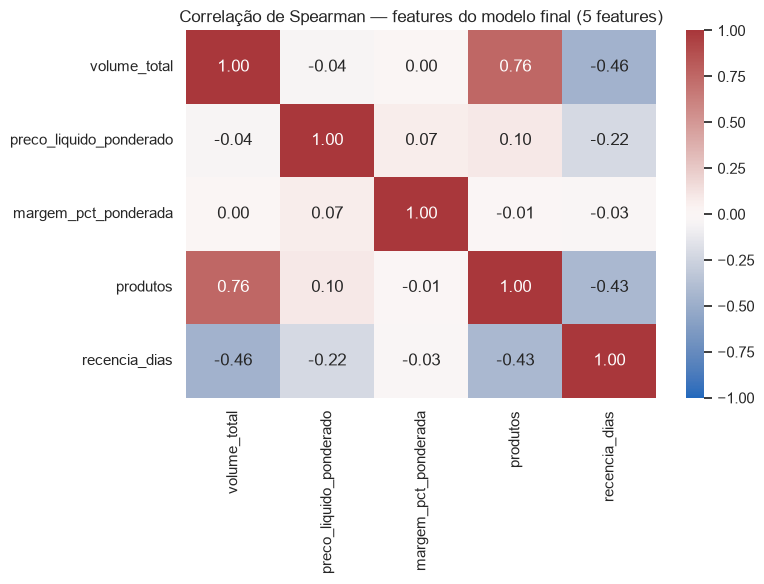

Pares com |correlação| >= 0.90:


,resultado
0,nenhum par redundante


In [6]:
corr = data[FEATURES].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlação de Spearman — features do modelo final (5 features)')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_correlacao_spearman_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

redundantes = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        if abs(corr.loc[a, b]) >= 0.90:
            redundantes.append({'variável A': a, 'variável B': b, 'correlação': round(corr.loc[a, b], 3)})
print('Pares com |correlação| >= 0.90:')
display(pd.DataFrame(redundantes) if redundantes else pd.DataFrame({'resultado': ['nenhum par redundante']}))


## 5. Preparar dados (imputação + escala robusta)

In [7]:
X = data[FEATURES].fillna(data[FEATURES].mean())
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print(f"Matriz escalada: {X_scaled.shape}")


Matriz escalada: (7050, 5)


## 6. Varredura de k — mantemos 3 ou 4?

Sweep completo de k=2 a 10 com o conjunto final de 5 features. Mostramos k=3 e k=4 lado a lado (além da tabela completa) porque o k=4 revelou, no teste anterior com 6 features, um grupo pequeno pagando preço bem acima da média — vale conferir se esse padrão se mantém aqui.


In [8]:
cmp_k, modelos_k = sweep_k(X_scaled, range(2, 11))
display(cmp_k.round(4))


,k,inercia,silhueta,davies_bouldin,min_cluster,max_cluster,balance_%
0,2,29263.2982,0.6121,0.7686,564,6486,8.6957
1,3,23647.4650,0.3648,1.0458,265,5589,4.7415
2,4,19566.9467,0.3186,1.1048,265,4656,5.6916
3,5,17261.0765,0.2388,1.2324,233,3343,6.9698
4,6,15326.1058,0.2361,1.1681,144,2899,4.9672
5,7,13632.8676,0.2475,1.1268,110,2645,4.1588
6,8,12711.4337,0.2294,1.1900,85,2148,3.9572
7,9,11920.0120,0.2235,1.1763,88,1755,5.0142
8,10,11321.8348,0.2248,1.1509,43,1769,2.4308


k com maior silhueta (regra padrão, k>=3): 3
k escolhido (decisão de negócio): 4


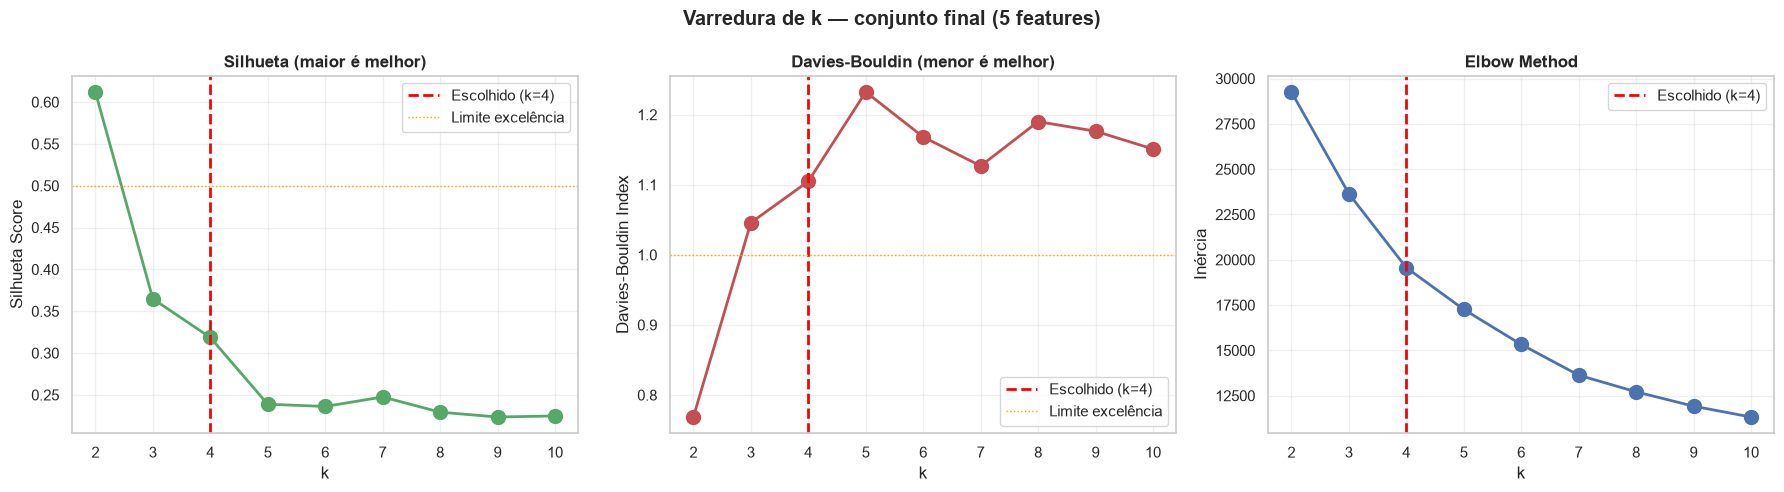

✓ 02_comparativo_k.png salvo em: 5.Figures


In [9]:
cmp_validos = cmp_k[cmp_k['k'] >= 3]
k_maior_silhueta = int(cmp_validos.loc[cmp_validos['silhueta'].idxmax(), 'k'])
print(f"k com maior silhueta (regra padrão, k>=3): {k_maior_silhueta}")

# Decisão do cliente: k=4, não k=3. Embora k=3 tenha silhueta um pouco maior (0.365 vs 0.319),
# k=4 revela um segmento de negócio real e acionável que k=3 esconde dentro do cluster grande:
# ~14% da base é pequena em volume mas paga preço bem acima da média (ver seção anterior,
# comparação lado a lado k=3 vs k=4) — candidatos a revisão de desconto por volume.
k_escolhido = 4
print(f"k escolhido (decisão de negócio): {k_escolhido}")

plot_comparativo_k(cmp_k, k_escolhido, 'Varredura de k — conjunto final (5 features)',
                   dirs=[FIG_DIR], filename='02_comparativo_k.png')


### k=3 vs. k=4 — comparação lado a lado

In [10]:
from sklearn.metrics import adjusted_rand_score

km3, labels3 = modelos_k[3]
km4, labels4 = modelos_k[4]
sil3, db3 = silhouette_score(X_scaled, labels3), davies_bouldin_score(X_scaled, labels3)
sil4, db4 = silhouette_score(X_scaled, labels4), davies_bouldin_score(X_scaled, labels4)
ari34 = adjusted_rand_score(labels3, labels4)

print(f"k=3 | silhueta={sil3:.4f} | DB={db3:.4f}")
print(f"k=4 | silhueta={sil4:.4f} | DB={db4:.4f} | ARI vs k=3={ari34:.3f}\n")

data_cmp = data.copy()
print('Perfil dos clusters em k=3:')
data_cmp['cluster3'] = labels3
display(data_cmp.groupby('cluster3')[FEATURES].mean().round(3))
print(f"Distribuição k=3: {dict(pd.Series(labels3).value_counts(normalize=True).round(3).sort_index() * 100)}\n")

print('Perfil dos clusters em k=4:')
data_cmp['cluster4'] = labels4
display(data_cmp.groupby('cluster4')[FEATURES].mean().round(3))
print(f"Distribuição k=4: {dict(pd.Series(labels4).value_counts(normalize=True).round(3).sort_index() * 100)}")


k=3 | silhueta=0.3648 | DB=1.0458
k=4 | silhueta=0.3186 | DB=1.1048 | ARI vs k=3=0.620

Perfil dos clusters em k=3:


,volume_total,preco_liquido_ponderado,margem_pct_ponderada,produtos,recencia_dias
cluster3,,,,,
0,26.703,13154.044,0.159,17.482,117.569
1,3.297,13397.913,0.161,5.260,393.221
2,87.753,12464.398,0.151,23.913,110.328


Distribuição k=3: {0: np.float64(17.0), 1: np.float64(79.3), 2: np.float64(3.8)}

Perfil dos clusters em k=4:


,volume_total,preco_liquido_ponderado,margem_pct_ponderada,produtos,recencia_dias
cluster4,,,,,
0,3.551,12326.259,0.164,5.391,420.552
1,87.753,12464.398,0.151,23.913,110.328
2,2.892,18514.147,0.143,5.221,248.892
3,27.358,13037.132,0.160,17.678,116.567


Distribuição k=4: {0: np.float64(66.0), 1: np.float64(3.8), 2: np.float64(14.2), 3: np.float64(16.0)}


## 7. Treino do modelo final

In [11]:
FINAL_K = k_escolhido
kmeans_final, clusters_final = modelos_k[FINAL_K]

silhouette_final = silhouette_score(X_scaled, clusters_final)
db_final = davies_bouldin_score(X_scaled, clusters_final)

print(f"k={FINAL_K} | Silhueta: {silhouette_final:.4f} ({interpretar_silhueta(silhouette_final)}) | "
      f"Davies-Bouldin: {db_final:.4f} ({interpretar_db(db_final)})")

# Nomes de negócio dos clusters (definidos a partir do perfil numérico -- ver seção 9/conclusão)
NOMES_CLUSTER = {0: 'Pequeno', 1: 'Grande', 2: 'Especial', 3: 'Médio'}

data_final = data.copy()
data_final['cluster'] = clusters_final
data_final['cluster_nome'] = data_final['cluster'].map(NOMES_CLUSTER)
print("\nDistribuição de clusters:")
dist_final = data_final['cluster'].value_counts().sort_index()
pct_final = (dist_final / dist_final.sum() * 100).round(1)
for c, n, p in zip(dist_final.index, dist_final.values, pct_final.values):
    print(f"  Cluster {c} ({NOMES_CLUSTER[c]}): {n:,} clientes ({p}%) — {interpretar_balance(p)}")


k=4 | Silhueta: 0.3186 (Aceitável) | Davies-Bouldin: 1.1048 (Aceitável)

Distribuição de clusters:
  Cluster 0 (Pequeno): 4,656 clientes (66.0%) — Bem balanceado
  Cluster 1 (Grande): 265 clientes (3.8%) — Desbalanceado, mas usável comercialmente
  Cluster 2 (Especial): 998 clientes (14.2%) — Desbalanceado, mas usável comercialmente
  Cluster 3 (Médio): 1,131 clientes (16.0%) — Bem balanceado


## 8. Diagnóstico do modelo

### 8.1 Silhueta detalhada por cluster

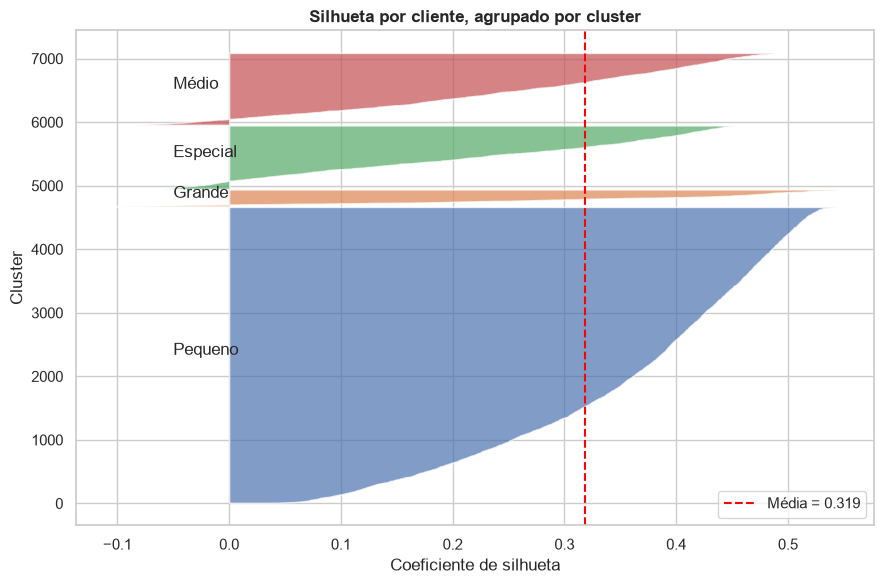

In [12]:
sample_sil = silhouette_samples(X_scaled, clusters_final)
fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for c in range(FINAL_K):
    vals = np.sort(sample_sil[clusters_final == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    ax.text(-0.05, y_lower + len(vals) / 2, NOMES_CLUSTER.get(c, str(c)))
    y_lower = y_upper + 10
ax.axvline(x=silhouette_final, color='red', linestyle='--', label=f'Média = {silhouette_final:.3f}')
ax.set_xlabel('Coeficiente de silhueta'); ax.set_ylabel('Cluster')
ax.set_title('Silhueta por cliente, agrupado por cluster', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '03_silhouette_by_cluster.png', dpi=300, bbox_inches='tight')
plt.show()


### 8.2 PCA 2D com centroides

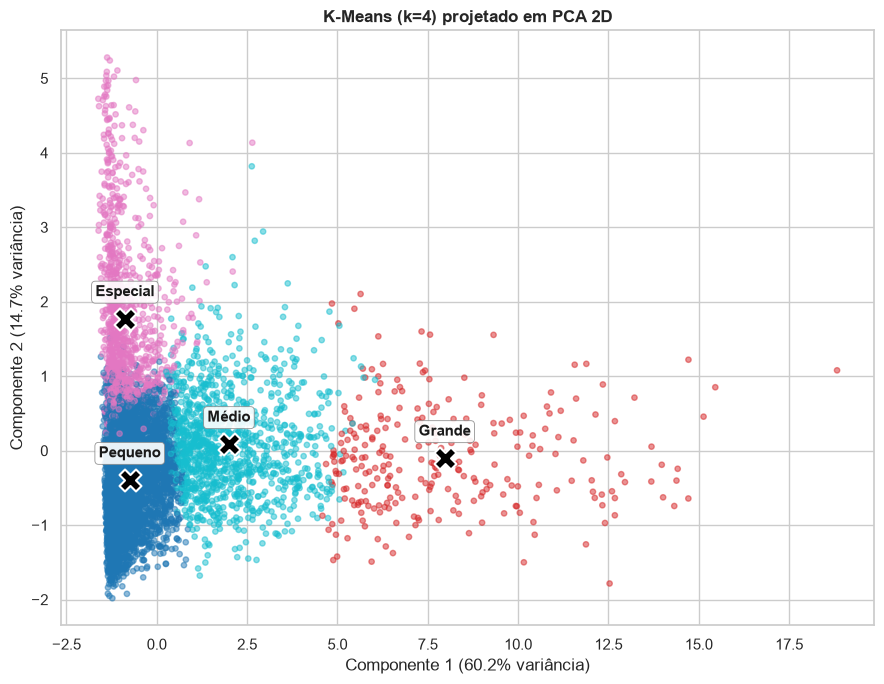

Variância explicada pelos 2 componentes: 74.9%


In [13]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_final, cmap='tab10', alpha=0.5, s=15)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=250, edgecolor='white', linewidth=1.5)
for i, (x, y) in enumerate(centroids_pca):
    plt.annotate(NOMES_CLUSTER.get(i, str(i)), (x, y), xytext=(0, 14), textcoords='offset points',
                 fontsize=11, fontweight='bold', ha='center', va='bottom', color='#1a1a1a',
                 bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#888888', alpha=0.9, linewidth=0.6))
plt.xlabel(f'Componente 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'Componente 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title(f'K-Means (k={FINAL_K}) projetado em PCA 2D', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_kmeans_pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Variância explicada pelos 2 componentes: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")


### 8.3 Boxplots por cluster

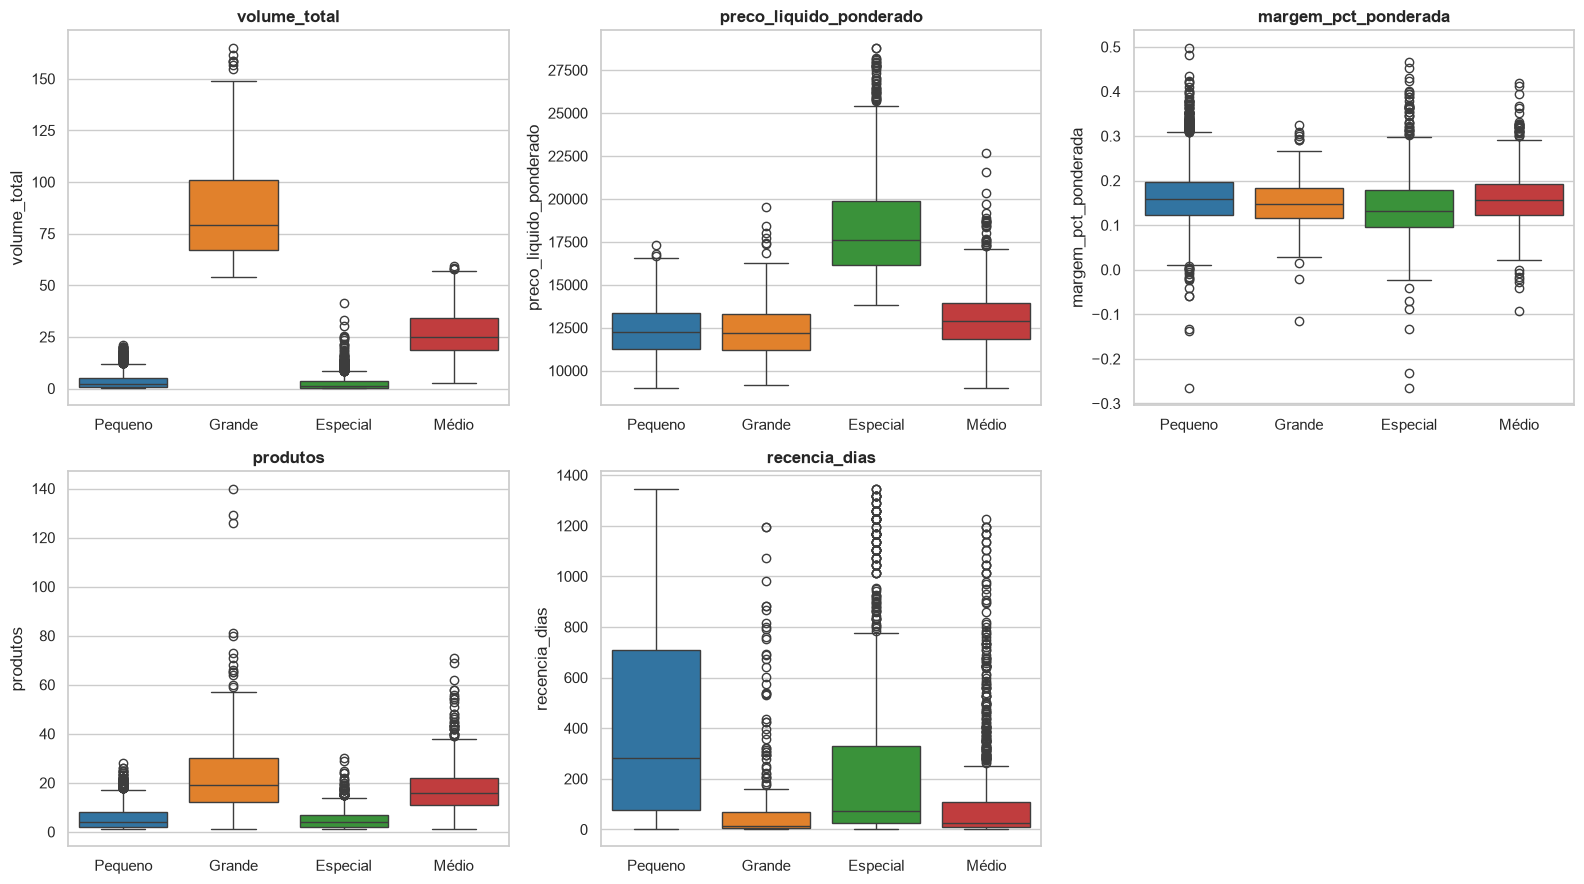

In [14]:
n_feat = len(FEATURES)
ncols = 3
nrows = -(-n_feat // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, feat in zip(axes, FEATURES):
    sns.boxplot(data=data_final, x='cluster_nome', y=feat, ax=ax, palette='tab10',
                order=[NOMES_CLUSTER[k] for k in sorted(NOMES_CLUSTER)])
    ax.set_xlabel('')
    ax.set_title(feat, fontweight='bold')
for ax in axes[n_feat:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Perfil dos clusters

Médias das features do modelo, mais o enriquecimento com `cnae_descricao` (não usado no treino).


In [15]:
perfil = data_final.groupby('cluster')[FEATURES].mean().round(3)
display(perfil)


,volume_total,preco_liquido_ponderado,margem_pct_ponderada,produtos,recencia_dias
cluster,,,,,
0,3.551,12326.259,0.164,5.391,420.552
1,87.753,12464.398,0.151,23.913,110.328
2,2.892,18514.147,0.143,5.221,248.892
3,27.358,13037.132,0.160,17.678,116.567


In [16]:
print("Distribuição de CNAE por cluster (% de clientes, top 5 por cluster):\n")
for c in range(FINAL_K):
    sub = data_final.loc[data_final['cluster'] == c, 'cnae_descricao']
    dist = sub.value_counts(normalize=True).head(5) * 100
    print(f"Cluster {c} ({len(sub):,} clientes):")
    for seg, pct in dist.items():
        print(f"  {seg}: {pct:.1f}%")
    print()


Distribuição de CNAE por cluster (% de clientes, top 5 por cluster):

Cluster 0 (4,656 clientes):
  Transporte rodoviário de carga, exceto produtos perigosos e mudanças, intermunicipal, interestadual e internacional: 16.0%
  Transporte rodoviário coletivo de passageiros, com itinerário fixo, municipal: 6.0%
  Construção de rodovias e ferrovias: 4.6%
  Aluguel de máquinas e equipamentos para construção sem operador, exceto andaimes: 3.7%
  Transporte rodoviário de produtos perigosos: 3.3%

Cluster 1 (265 clientes):
  Transporte rodoviário de carga, exceto produtos perigosos e mudanças, intermunicipal, interestadual e internacional: 14.8%
  Transporte rodoviário coletivo de passageiros, com itinerário fixo, municipal: 12.1%
  Transporte rodoviário coletivo de passageiros, com itinerário fixo, intermunicipal em região metropolitana: 5.3%
  Construção de rodovias e ferrovias: 4.5%
  Extração e britamento de pedras e outros materiais para construção e beneficiamento associado: 3.8%

Cluster

## 10. Salvar artefatos do modelo final

In [17]:
joblib.dump(kmeans_final, OUTPUT_DIR / 'kmeans_model.pkl')
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
joblib.dump(pca_2d, OUTPUT_DIR / 'pca_2d.pkl')
print("✓ Modelos salvos: kmeans_model.pkl, scaler.pkl, pca_2d.pkl")


✓ Modelos salvos: kmeans_model.pkl, scaler.pkl, pca_2d.pkl


In [18]:
export_cols = ['Código Cliente', 'nome_cliente', 'cnae_descricao'] + FEATURES + ['receita_liquida_total', 'cluster']
output_export = data_final[export_cols].sort_values('cluster').copy()
salvar_csv(output_export, 'segmentacao_clientes_kmeans.csv', dirs=[OUTPUT_DIR], index=False, encoding='utf-8-sig')
display(output_export.head(10))

resumo_clusters = data_final.groupby('cluster')[FEATURES].agg(['count', 'mean', 'std', 'min', 'max'])
salvar_csv(resumo_clusters, 'resumo_clusters.csv', dirs=[OUTPUT_DIR], encoding='utf-8-sig')


✓ segmentacao_clientes_kmeans.csv salvo em: 2. Clusterização


,Código Cliente,nome_cliente,cnae_descricao,volume_total,preco_liquido_ponderado,margem_pct_ponderada,produtos,recencia_dias,receita_liquida_total,cluster
7326,1914210,CENTRAL FISH COMERCIO DE PESCADOS L,"Preservação de peixes, crustáceos e moluscos",0.20,13187.900000,0.227481,1,39,2637.58,0
7323,1912219,M.G. CINDIO MANUTENCAO DE BOMBAS LT,Comércio atacadista de Máquinas e equipamentos...,0.70,13458.914286,0.059395,2,8,9421.24,0
19,1481,COMANDO DA MARINHA,Defesa,2.20,13668.868182,0.177896,2,830,30071.51,0
17,1469,COMANDO DA MARINHA,Defesa,1.92,12742.625000,0.228668,12,100,24465.84,0
16,1439,COMANDO DO EXERCITO,Defesa,1.62,10834.814815,0.052375,1,1074,17552.40,0
14,1007,CENTRAIS ELETRICAS DO NORTE DO BRAS,Transmissão de energia elétrica,0.06,12848.666667,0.295789,1,345,770.92,0
13,1006,CENTRAIS ELETRICAS DO NORTE DO BRAS,Transmissão de energia elétrica,4.00,11434.117500,0.126201,1,211,45736.47,0
12,924,TRANSPORTADORA PLANALTO LTDA,Transporte rodoviário de produtos perigosos,0.32,14287.656250,0.154207,2,1257,4572.05,0
8,618,CARAMURU ALIMENTOS S/A,"Fabricação de óleos vegetais refinados, exceto...",17.60,9734.364205,0.158456,1,0,171324.81,0
7,574,CIPLAN CIMENTO PLANALTO SA,Preparação de massa de concreto e argamassa pa...,12.16,10500.332237,0.143318,6,35,127684.04,0


✓ resumo_clusters.csv salvo em: 2. Clusterização


## 11. Recomendações de estratégia de pricing por cluster

In [19]:
recommendations = []
for cluster_id in range(FINAL_K):
    cd = data_final[data_final['cluster'] == cluster_id]
    means = cd[FEATURES].mean()
    volume = means['volume_total']
    recencia = means['recencia_dias']
    if volume > data_final['volume_total'].quantile(0.75):
        strategy = "Volume Pricing: desconto por volume"
    elif recencia > data_final['recencia_dias'].quantile(0.75):
        strategy = "Reativação: cliente com baixa recência recente, ação comercial de retomada"
    else:
        strategy = "Standard Pricing: preço base com pequenos ajustes"
    recommendations.append({
        'cluster': cluster_id, 'n_clientes': len(cd), 'pct_total': f"{len(cd) / len(data_final) * 100:.1f}%",
        'volume_medio': round(means['volume_total'], 2), 'produtos_medio': round(means['produtos'], 2),
        'recencia_media_dias': round(recencia, 1), 'estrategia': strategy,
    })
rec_df = pd.DataFrame(recommendations)
print("RECOMENDAÇÕES DE ESTRATÉGIA DE PRICING")
display(rec_df)
salvar_csv(rec_df, 'recomendacoes_pricing.csv', dirs=[OUTPUT_DIR], index=False, encoding='utf-8-sig')


RECOMENDAÇÕES DE ESTRATÉGIA DE PRICING


,cluster,n_clientes,pct_total,volume_medio,produtos_medio,recencia_media_dias,estrategia
0,0,4656,66.0%,3.55,5.39,420.6,Standard Pricing: preço base com pequenos ajustes
1,1,265,3.8%,87.75,23.91,110.3,Volume Pricing: desconto por volume
2,2,998,14.2%,2.89,5.22,248.9,Standard Pricing: preço base com pequenos ajustes
3,3,1131,16.0%,27.36,17.68,116.6,Volume Pricing: desconto por volume


✓ recomendacoes_pricing.csv salvo em: 2. Clusterização


## 12. Conclusão

Modelo final: K-Means com 5 features (`volume_total`, `preco_liquido_ponderado`, `margem_pct_ponderada`, `produtos`, `recencia_dias`), sem `taxa_devolucao`, `frequencia_mensal`, `concentracao_familia` nem `intensidade_desconto` — todas testadas e descartadas por evidência (a versão corrigida de frequência de compra chegou a melhorar as métricas, mas dissolvia o cluster Especial — seção 14 — e por isso também ficou fora). Sem a família AV (excluída da base a pedido do cliente). `cnae_descricao` fica como dimensão de leitura do perfil, não como input do treino. k=4 foi escolhido (não k=3, que tem silhueta levemente maior) porque revela um segmento de negócio real: ~14% da base é pequena em volume mas paga preço bem acima da média, com a menor margem de todos os clusters — candidatos a revisão de desconto por volume (ver seção 6).


## 13. Teste de ablação — `frete_por_m3` adiciona informação?

Motivado pelo achado de UF (seção 5.5 da segmentação híbrida): Mato Grosso/MS estão sobrerrepresentados no cluster Especial, e o frete médio deles é 63% mais alto que o resto da base — pista de que parte do preço mais alto do Especial é logística. `frete_por_m3` (soma de frete ÷ soma de volume, limpa de outliers p01–p99) tem correlação de Spearman fraca com `preco_liquido_ponderado` (0,13–0,17 numa checagem exploratória) — não é a mesma informação disfarçada. Testamos por ablação: mesma população, mesmo k, comparando com/sem.


In [20]:
corr_frete = data[FEATURES + ['frete_por_m3']].corr(method='spearman')
print("Correlação de frete_por_m3 com as features do modelo:")
display(corr_frete['frete_por_m3'].round(3))


Correlação de frete_por_m3 com as features do modelo:


volume_total              -0.012
preco_liquido_ponderado    0.135
margem_pct_ponderada      -0.175
produtos                  -0.029
recencia_dias             -0.074
frete_por_m3               1.000
Name: frete_por_m3, dtype: float64

In [21]:
FEATURES_COM_FRETE = FEATURES + ['frete_por_m3']
X_frete = data[FEATURES_COM_FRETE].fillna(data[FEATURES_COM_FRETE].mean())
scaler_frete = RobustScaler()
X_frete_scaled = scaler_frete.fit_transform(X_frete)

km_frete = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20, max_iter=500, tol=1e-4)
labels_frete = km_frete.fit_predict(X_frete_scaled)
sil_frete = silhouette_score(X_frete_scaled, labels_frete)
db_frete = davies_bouldin_score(X_frete_scaled, labels_frete)
ari_frete = adjusted_rand_score(clusters_final, labels_frete)

print(f"{'Atual (5 features)':30s} | silhueta={silhouette_final:.4f} | DB={db_final:.4f} | ARI vs atual=1.000")
print(f"{'+ frete_por_m3 (6 features)':30s} | silhueta={sil_frete:.4f} | DB={db_frete:.4f} | "
      f"ARI vs atual={ari_frete:.3f}")

dist_frete = pd.Series(labels_frete).value_counts(normalize=True).sort_index() * 100
print(f"\nDistribuição com frete: maior cluster={dist_frete.max():.1f}% | menor={dist_frete.min():.1f}%")
print(f"Distribuição atual:     maior cluster={(pd.Series(clusters_final).value_counts(normalize=True).max()*100):.1f}% | "
      f"menor={(pd.Series(clusters_final).value_counts(normalize=True).min()*100):.1f}%")


Atual (5 features)             | silhueta=0.3186 | DB=1.1048 | ARI vs atual=1.000
+ frete_por_m3 (6 features)    | silhueta=0.2462 | DB=1.3742 | ARI vs atual=0.694

Distribuição com frete: maior cluster=58.9% | menor=3.7%
Distribuição atual:     maior cluster=66.0% | menor=3.8%


### Leitura

Mesmo critério de sempre: silhueta/DB parecidos ou melhores **e** ARI baixo (realocação real) seria sinal de que frete traz informação nova de segmentação. Silhueta/DB piores e/ou ARI muito próximo de 1 indicam que a variável não muda a segmentação.


**Decisão:** `frete_por_m3` **descartada** como feature do K-Means — piora silhueta (0,246 vs. 0,319) e Davies-Bouldin (1,374 vs. 1,105), com ARI=0,694 (realocação real, mas não compensa a perda de qualidade). Mesmo padrão de `intensidade_desconto` (seção 7): reembaralha a segmentação sem separar melhor os grupos. Continua valiosa como **enriquecimento** (não como input do treino) — é o que já usamos para explicar o achado de frete/UF do grupo Especial (`4.Segmentacao-Hibrida.ipynb`, seção 5.5).


## 14. Teste de ablação — `frequencia_mensal_corrigida` adiciona informação?

A tabela de variáveis descartadas (seção 3, relatório) citava só o motivo antigo de `frequencia_mensal` (contaminada por pedidos fraturados em várias remessas). Esse problema **já foi corrigido** — `frequencia_mensal_corrigida` conta pedidos únicos (`DOC_VENDA`) via `pedidos.csv`, não linhas de remessa (`1.EDA_Kmeans.ipynb`, seção 9.1) — mas a versão corrigida nunca tinha passado pelo mesmo teste de ablação usado nas outras candidatas. Testando agora, mesmo critério de sempre: mesma população, mesmo k, com/sem.


In [22]:
corr_freq = data[FEATURES + ['frequencia_mensal_corrigida']].corr(method='spearman')
print("Correlação de frequencia_mensal_corrigida com as features do modelo:")
display(corr_freq['frequencia_mensal_corrigida'].round(3))


Correlação de frequencia_mensal_corrigida com as features do modelo:


volume_total                   0.470
preco_liquido_ponderado        0.075
margem_pct_ponderada          -0.020
produtos                       0.551
recencia_dias                 -0.188
frequencia_mensal_corrigida    1.000
Name: frequencia_mensal_corrigida, dtype: float64

In [23]:
FEATURES_COM_FREQ = FEATURES + ['frequencia_mensal_corrigida']
X_freq = data[FEATURES_COM_FREQ].fillna(data[FEATURES_COM_FREQ].mean())
scaler_freq = RobustScaler()
X_freq_scaled = scaler_freq.fit_transform(X_freq)

km_freq = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20, max_iter=500, tol=1e-4)
labels_freq = km_freq.fit_predict(X_freq_scaled)
sil_freq = silhouette_score(X_freq_scaled, labels_freq)
db_freq = davies_bouldin_score(X_freq_scaled, labels_freq)
ari_freq = adjusted_rand_score(clusters_final, labels_freq)

print(f"{'Atual (5 features)':30s} | silhueta={silhouette_final:.4f} | DB={db_final:.4f} | ARI vs atual=1.000")
print(f"{'+ frequencia_corrigida (6 features)':30s} | silhueta={sil_freq:.4f} | DB={db_freq:.4f} | "
      f"ARI vs atual={ari_freq:.3f}")


Atual (5 features)             | silhueta=0.3186 | DB=1.1048 | ARI vs atual=1.000
+ frequencia_corrigida (6 features) | silhueta=0.3436 | DB=1.0787 | ARI vs atual=0.554


### Leitura

Mesmo critério de sempre: silhueta/DB parecidos ou melhores **e** ARI baixo (realocação real) seria sinal de que frequência de compra traz informação nova de segmentação. Silhueta/DB piores e/ou ARI muito próximo de 1 indicam que a variável não muda a segmentação.


In [24]:
# Onde os clientes do cluster Especial (modelo atual) vão parar no candidato de 6 features?
data_cmp_freq = data.copy()
data_cmp_freq['cluster_atual_nome'] = pd.Series(clusters_final, index=data.index).map(NOMES_CLUSTER)
data_cmp_freq['cluster_candidato'] = labels_freq

print("Perfil dos clusters no candidato de 6 features:")
perfil_freq = data_cmp_freq.groupby('cluster_candidato')[FEATURES_COM_FREQ].mean().round(2)
perfil_freq['n_clientes'] = data_cmp_freq['cluster_candidato'].value_counts()
display(perfil_freq.sort_values('volume_total'))

print("\nComo o cluster Especial atual (5 features) se redistribui no candidato (6 features), em %:")
ct_freq = pd.crosstab(data_cmp_freq['cluster_atual_nome'], data_cmp_freq['cluster_candidato'], normalize='index') * 100
display(ct_freq.round(1))


Perfil dos clusters no candidato de 6 features:


,volume_total,preco_liquido_ponderado,margem_pct_ponderada,produtos,recencia_dias,frequencia_mensal_corrigida,n_clientes
cluster_candidato,,,,,,,
1,3.36,13390.77,0.16,5.19,379.43,1.32,5436
0,11.62,13349.85,0.15,14.27,629.44,5.83,279
3,27.33,13158.23,0.16,16.86,95.58,1.82,1081
2,88.79,12501.41,0.15,24.59,102.54,2.73,254



Como o cluster Especial atual (5 features) se redistribui no candidato (6 features), em %:


cluster_candidato,0,1,2,3
cluster_atual_nome,,,,
Especial,3.5,93.8,0.0,2.7
Grande,1.5,0.0,94.3,4.2
Médio,7.1,3.7,0.4,88.9
Pequeno,3.4,95.7,0.0,0.8


**Decisão:** `frequencia_mensal_corrigida` **melhora as métricas** (silhueta 0,3436 vs. 0,3186; Davies-Bouldin 1,0787 vs. 1,1048) e reorganiza clientes de verdade (ARI=0,554) — diferente de todas as outras candidatas testadas neste notebook, que pioravam pelo menos uma métrica. Ainda assim, **optamos por não adicioná-la ao K-Means**: olhando o perfil dos clusters e o cruzamento acima, 93,8% dos clientes do grupo **Especial** (o achado central desta segmentação — preço ~50% acima da média, pior margem) são absorvidos pelo mesmo cluster que recebe 95,7% do grupo **Pequeno**, e o preço médio desse cluster combinado (R$ 13.391/m³) fica perto do Pequeno, não do Especial — o sinal de preço que define o Especial se dilui. É uma troca real: métricas agregadas um pouco melhores, mas o segmento de negócio mais acionável do projeto deixa de existir como grupo isolado. Optamos pelo modelo de 5 features. `frequencia_mensal_corrigida` segue disponível como **enriquecimento** (`nivel_frequencia`, `4.Segmentacao-Hibrida.ipynb`).
